In [1]:
import os, re, cv2, torch, pandas as pd
import torchvision.models as models
import torchvision.transforms as transforms
from pathlib import Path


image_folder = Path(r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\classification_level1\AND_result_fold2")
label_path  = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\scientificProject\data\labels.csv"
label_df = pd.read_csv(label_path)
label_df["name"] = label_df["name"].astype(str)
label = {}
for item in range(len(label_df['name'])):
    label[int(label_df['name'][item].split('.')[0])] = label_df['grade'][item]
    

In [58]:
import os, re, cv2, torch, pandas as pd
import torchvision.models as models
import torchvision.transforms as transforms
from pathlib import Path


image_folder = Path(r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\classification_level1\AND_result_fold2")


def get_id(filename: str) -> int:
    return int(re.findall(r'\d+', Path(filename).stem)[0])


image_files = sorted(
    [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.png'))],
    key=get_id
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models_config = [
    ('vit_tiny', lambda: torch.hub.load('facebookresearch/dino:main', 'dino_vits16'), 'features_ViTTiny2.xlsx')
]

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

for model_name, model_fn, output_name in models_config:

    if 'vit' in model_name:
        model = model_fn().to(device).eval()
    else:
        model = model_fn(pretrained=True).to(device).eval()
    
    all_rows = []          
    
    for img_file in image_files:
        img_path = image_folder / img_file
        img_id   = get_id(img_file)     
        
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            feats = model(img_tensor).cpu().numpy().flatten()
        

        row = [img_id] + feats.tolist()
        all_rows.append(row)
    

    df = pd.DataFrame(all_rows)
    df.to_excel(output_name, index=False, header=False)
    print(f"{output_name} saved ✅")


Using cache found in C:\Users\Meta Pc/.cache\torch\hub\facebookresearch_dino_main


features_ViTTiny2.xlsx saved ✅


In [59]:
image_folder = Path(r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\classification_level1\AND_result_test")


def get_id(filename: str) -> int:
    return int(re.findall(r'\d+', Path(filename).stem)[0])


image_files = sorted(
    [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.png'))],
    key=get_id
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models_config = [
    ('vit_tiny', lambda: torch.hub.load('facebookresearch/dino:main', 'dino_vits16'), 'features_ViTTiny_TEST2.xlsx')
]

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

for model_name, model_fn, output_name in models_config:

    if 'vit' in model_name:
        model = model_fn().to(device).eval()
    else:
        model = model_fn(pretrained=True).to(device).eval()
    
    all_rows = []          
    
    for img_file in image_files:
        img_path = image_folder / img_file
        img_id   = get_id(img_file)     
        
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            feats = model(img_tensor).cpu().numpy().flatten()
        

        row = [img_id] + feats.tolist()
        all_rows.append(row)
    

    df = pd.DataFrame(all_rows)
    df.to_excel(output_name, index=False, header=False)
    print(f"{output_name} saved ✅")


Using cache found in C:\Users\Meta Pc/.cache\torch\hub\facebookresearch_dino_main


features_ViTTiny_TEST2.xlsx saved ✅


In [56]:
import pandas as pd
import numpy as np

train_df = pd.read_excel("features_ViTTiny2.xlsx", header=None)
test_df = pd.read_excel("features_ViTTiny_TEST2.xlsx", header=None)

train_ids = train_df.iloc[:, 0].astype(int)
test_ids = test_df.iloc[:, 0].astype(int)

X_train = train_df.iloc[:, 1:].values
X_test = test_df.iloc[:, 1:].values


def map_label(original_label):
    if original_label in [0, 1]:
        return 0
    elif original_label in [2, 3]:
        return 1
    elif original_label == 4:
        return 2
    else:
        return 0 



y_train = np.array([map_label(label.get(i, 0)) for i in train_ids])
y_test = np.array([map_label(label.get(i, 0)) for i in test_ids])


RF

Epoch 1/40 - Train Loss: 0.7971 - Test Loss: 0.8183 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 2/40 - Train Loss: 0.7454 - Test Loss: 0.7805 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 3/40 - Train Loss: 0.7667 - Test Loss: 0.7945 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 4/40 - Train Loss: 0.7059 - Test Loss: 0.7614 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 5/40 - Train Loss: 0.6906 - Test Loss: 0.7519 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 6/40 - Train Loss: 0.6900 - Test Loss: 0.7527 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 7/40 - Train Loss: 0.6669 - Test Loss: 0.7663 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 8/40 - Train Loss: 0.6799 - Test Loss: 0.7621 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 9/40 - Train Loss: 0.6675 - Test Loss: 0.7457 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 10/40 - Train Loss: 0.6582 - Test Loss: 0.7638 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 11/40 - Train Loss: 0.6633 - Test Loss: 0.7519 - Train Acc: 0.6702 - Test Acc: 0.66

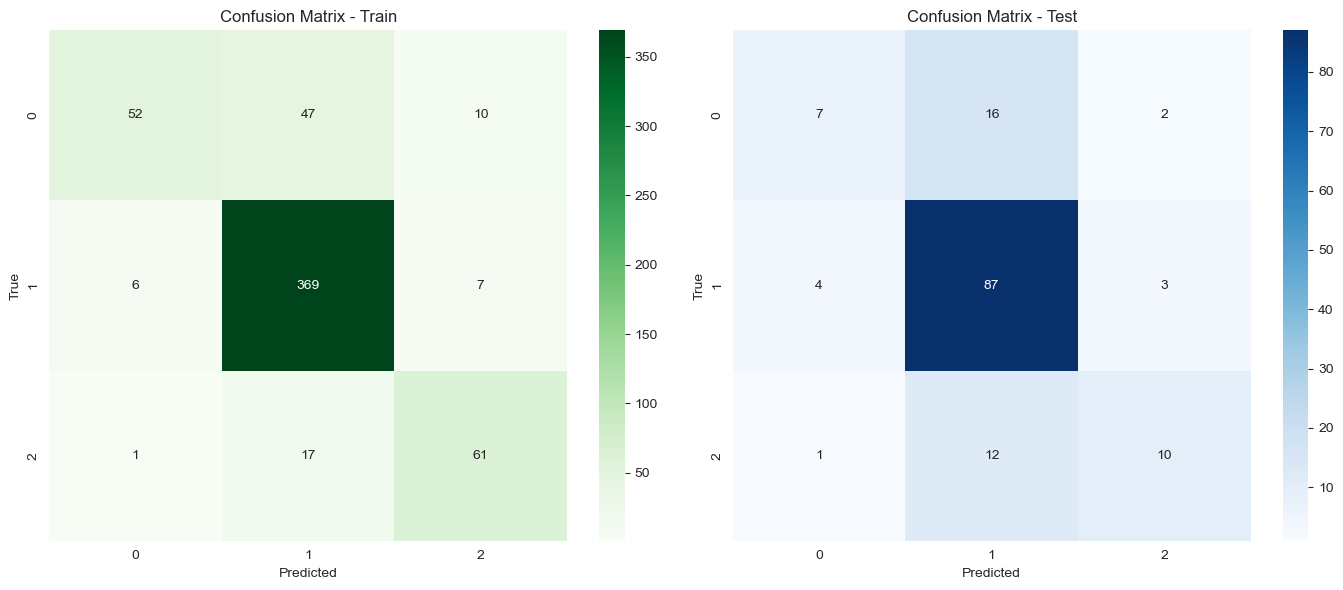


نمونه‌های تصادفی آموزش و پیش‌بینی مدل:
نمونه 1 - ایندکس 507 - لیبل واقعی: 2 - پیش‌بینی: 2
نمونه 2 - ایندکس 70 - لیبل واقعی: 1 - پیش‌بینی: 1
نمونه 3 - ایندکس 131 - لیبل واقعی: 1 - پیش‌بینی: 1
نمونه 4 - ایندکس 400 - لیبل واقعی: 1 - پیش‌بینی: 1
نمونه 5 - ایندکس 541 - لیبل واقعی: 2 - پیش‌بینی: 1

نمونه‌های تصادفی تست و پیش‌بینی مدل:
نمونه 1 - ایندکس 58 - لیبل واقعی: 0 - پیش‌بینی: 0
نمونه 2 - ایندکس 21 - لیبل واقعی: 1 - پیش‌بینی: 1
نمونه 3 - ایندکس 72 - لیبل واقعی: 1 - پیش‌بینی: 1
نمونه 4 - ایندکس 105 - لیبل واقعی: 0 - پیش‌بینی: 2
نمونه 5 - ایندکس 29 - لیبل واقعی: 1 - پیش‌بینی: 1


In [95]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 4
learning_rate = 0.0008
np.random.seed(42)
epochs = 40

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # برای اطمینان بیشتر (تاثیر احتمالی روی برخی الگوریتم‌های cudnn)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_enc, dtype=torch.long).to(device)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)


class SimpleNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 16), 
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
num_classes = len(le.classes_)

model = SimpleNN(input_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

def train(model, loader):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    return running_loss / len(loader.dataset)

def evaluate_with_loss(model, loader, criterion):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    return np.array(all_labels), np.array(all_preds), avg_loss

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    sens = recall_score(y_true, y_pred, average='macro')

    # Specificity calculation
    cm = confusion_matrix(y_true, y_pred)
    tn = []
    fp = []
    for i in range(len(cm)):
        true_neg = np.delete(np.delete(cm, i, axis=0), i, axis=1).sum()
        false_pos = np.delete(cm[:, i], i).sum()
        tn.append(true_neg)
        fp.append(false_pos)
    spec_per_class = [tn[i] / (tn[i] + fp[i]) if (tn[i] + fp[i]) > 0 else 0 for i in range(len(cm))]
    spec = np.mean(spec_per_class)
    return acc, balanced_acc, spec, sens, f1

best_acc = 0

train_losses = []
test_losses = []

for epoch in range(epochs):
    train_loss = train(model, train_loader)
    y_true_train, y_pred_train, train_loss_eval = evaluate_with_loss(model, train_loader, criterion)
    y_true_test, y_pred_test, test_loss = evaluate_with_loss(model, test_loader, criterion)

    train_losses.append(train_loss_eval)
    test_losses.append(test_loss)

    train_acc = (y_true_train == y_pred_train).mean()
    test_acc = (y_true_test == y_pred_test).mean()

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss_eval:.4f} - Test Loss: {test_loss:.4f} - Train Acc: {train_acc:.4f} - Test Acc: {test_acc:.4f}")

model.load_state_dict(torch.load("best_model.pth"))

train_acc, train_bal_acc, train_spec, train_sens, train_f1 = compute_metrics(y_true_train, y_pred_train)
test_acc, test_bal_acc, test_spec, test_sens, test_f1 = compute_metrics(y_true_test, y_pred_test)

print("\n✨ دقت‌ها روی داده‌های آموزش:")
print(f"Accuracy: {train_acc:.4f}")
print(f"Balanced Accuracy: {train_bal_acc:.4f}")
print(f"Specificity: {train_spec:.4f}")
print(f"Sensitivity (Recall): {train_sens:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n✨ دقت‌ها روی داده‌های تست:")
print(f"Accuracy: {test_acc:.4f}")
print(f"Balanced Accuracy: {test_bal_acc:.4f}")
print(f"Specificity: {test_spec:.4f}")
print(f"Sensitivity (Recall): {test_sens:.4f}")
print(f"F1 Score: {test_f1:.4f}")

labels = le.classes_

cm_train = confusion_matrix(y_true_train, y_pred_train, labels=np.arange(len(labels)))
cm_test = confusion_matrix(y_true_test, y_pred_test, labels=np.arange(len(labels)))

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Confusion Matrix - Train')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('Confusion Matrix - Test')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()


train_samples_idx = np.random.choice(len(X_train), size=5, replace=False)
test_samples_idx = np.random.choice(len(X_test), size=5, replace=False)

model.eval()
with torch.no_grad():
    X_train_sample = torch.tensor(X_train[train_samples_idx], dtype=torch.float32).to(device)
    pred_train_sample = model(X_train_sample)
    pred_train_labels = le.inverse_transform(pred_train_sample.argmax(dim=1).cpu().numpy())

    X_test_sample = torch.tensor(X_test[test_samples_idx], dtype=torch.float32).to(device)
    pred_test_sample = model(X_test_sample)
    pred_test_labels = le.inverse_transform(pred_test_sample.argmax(dim=1).cpu().numpy())

print("\nنمونه‌های تصادفی آموزش و پیش‌بینی مدل:")
for i, idx in enumerate(train_samples_idx):
    print(f"نمونه {i+1} - ایندکس {idx} - لیبل واقعی: {le.inverse_transform([y_train_enc[idx]])[0]} - پیش‌بینی: {pred_train_labels[i]}")

print("\nنمونه‌های تصادفی تست و پیش‌بینی مدل:")
for i, idx in enumerate(test_samples_idx):
    print(f"نمونه {i+1} - ایندکس {idx} - لیبل واقعی: {le.inverse_transform([y_test_enc[idx]])[0]} - پیش‌بینی: {pred_test_labels[i]}")
    
# Test Acc: 00.7746
# batch_size = 4
# learning_rate = 0.0005
# np.random.seed(42)
# epochs = 60

In [ ]:
# batch_size = 4
# learning_rate = 0.0008
# np.random.seed(42)
# epochs = 60
# Test Acc: 0.7746

In [25]:
import os
import re
import cv2
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2

# تنظیم device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# مسیرها
train_image_folder = Path(r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\classification_level1\AND_result_fold2")
test_image_folder  = Path(r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\classification_level1\AND_result_test")
label_path = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\scientificProject\data\labels.csv"

# بارگذاری لیبل‌ها
label_df = pd.read_csv(label_path)
label_df["name"] = label_df["name"].astype(str)
label = {int(name.split('.')[0]): grade for name, grade in zip(label_df["name"], label_df["grade"])}

# تابع گرفتن id از اسم فایل
def get_id(filename: str) -> int:
    return int(re.findall(r'\d+', Path(filename).stem)[0])

# مرتب کردن فایل‌ها بر اساس id
def sorted_files(folder):
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))], key=get_id)

# بارگذاری مدل ViT با DINO
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16').to(device).eval()

# ✅ Augmentation بهینه‌شده برای داده‌های آموزش
augmentations = A.Compose([
    A.Resize(256, 256),
    A.CenterCrop(224, 224),

    A.OneOf([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
    ], p=0.5),

    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),

    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=5, p=0.3),

    A.GaussianBlur(blur_limit=(3, 5), p=0.1),

    A.Normalize(),
    ToTensorV2()
])

# ترنسفورم برای داده‌های تست (بدون augmentation)
test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2()
])

# استخراج فیچر برای داده‌های آموزش با augmentation
def extract_features_with_augmentation(image_folder, n_aug=2):
    all_rows = []
    image_files = sorted_files(image_folder)
    for img_file in image_files:
        img_path = image_folder / img_file
        img_id = get_id(img_file)
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        for _ in range(n_aug):
            augmented = augmentations(image=img)['image'].unsqueeze(0).to(device)
            with torch.no_grad():
                feats = model(augmented).cpu().numpy().flatten()
            row = [img_id] + feats.tolist()
            all_rows.append(row)
    return all_rows

# استخراج فیچر برای داده‌های تست بدون augmentation
def extract_features_without_augmentation(image_folder):
    all_rows = []
    image_files = sorted_files(image_folder)
    for img_file in image_files:
        img_path = image_folder / img_file
        img_id = get_id(img_file)
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        transformed = test_transform(image=img)['image'].unsqueeze(0).to(device)
        with torch.no_grad():
            feats = model(transformed).cpu().numpy().flatten()
        row = [img_id] + feats.tolist()
        all_rows.append(row)
    return all_rows

# استخراج و ذخیره داده‌ها
print("در حال استخراج فیچرهای آموزش با augmentation...")
train_features = extract_features_with_augmentation(train_image_folder, n_aug=2)
df_train = pd.DataFrame(train_features)
df_train.to_excel("augmented_features_train.xlsx", index=False, header=False)
print("فیچرهای آموزش ذخیره شد: augmented_features_train.xlsx")

print("در حال استخراج فیچرهای تست بدون augmentation...")
test_features = extract_features_without_augmentation(test_image_folder)
df_test = pd.DataFrame(test_features)
df_test.to_excel("features_test.xlsx", index=False, header=False)
print("فیچرهای تست ذخیره شد: features_test.xlsx")

# پردازش نهایی برای استفاده در MLP
train_df = df_train
test_df = df_test

train_ids = train_df.iloc[:, 0].astype(int)
test_ids = test_df.iloc[:, 0].astype(int)

X_train = train_df.iloc[:, 1:].values
X_test = test_df.iloc[:, 1:].values

# نگاشت لیبل‌ها به کلاس‌های نهایی
def map_label(original_label):
    if original_label in [0, 1]:
        return 0
    elif original_label in [2, 3]:
        return 1
    elif original_label == 4:
        return 2
    else:
        return 0

y_train = np.array([map_label(label.get(i, 0)) for i in train_ids])
y_test = np.array([map_label(label.get(i, 0)) for i in test_ids])

print("✅ لیبل‌ها ساخته شدند. آماده آموزش مدل هستی.")


Using cache found in C:\Users\Meta Pc/.cache\torch\hub\facebookresearch_dino_main


در حال استخراج فیچرهای آموزش با augmentation...
فیچرهای آموزش ذخیره شد: augmented_features_train.xlsx
در حال استخراج فیچرهای تست بدون augmentation...
فیچرهای تست ذخیره شد: features_test.xlsx
✅ لیبل‌ها ساخته شدند. آماده آموزش مدل هستی.


Epoch 1/40 - Train Loss: 0.7274 - Test Loss: 0.7819 - Train Acc: 0.6702 - Test Acc: 0.6620
Epoch 2/40 - Train Loss: 0.6538 - Test Loss: 0.7622 - Train Acc: 0.7044 - Test Acc: 0.6338
Epoch 3/40 - Train Loss: 0.6341 - Test Loss: 0.7600 - Train Acc: 0.7079 - Test Acc: 0.6761
Epoch 4/40 - Train Loss: 0.6170 - Test Loss: 0.7625 - Train Acc: 0.7132 - Test Acc: 0.6831
Epoch 5/40 - Train Loss: 0.5821 - Test Loss: 0.7401 - Train Acc: 0.7316 - Test Acc: 0.6831
Epoch 6/40 - Train Loss: 0.5689 - Test Loss: 0.7361 - Train Acc: 0.7693 - Test Acc: 0.7113
Epoch 7/40 - Train Loss: 0.5278 - Test Loss: 0.7139 - Train Acc: 0.7904 - Test Acc: 0.6972
Epoch 8/40 - Train Loss: 0.5303 - Test Loss: 0.6902 - Train Acc: 0.7605 - Test Acc: 0.7254
Epoch 9/40 - Train Loss: 0.5058 - Test Loss: 0.6839 - Train Acc: 0.7886 - Test Acc: 0.7254
Epoch 10/40 - Train Loss: 0.4879 - Test Loss: 0.7338 - Train Acc: 0.8061 - Test Acc: 0.7042
Epoch 11/40 - Train Loss: 0.4660 - Test Loss: 0.7127 - Train Acc: 0.8079 - Test Acc: 0.71

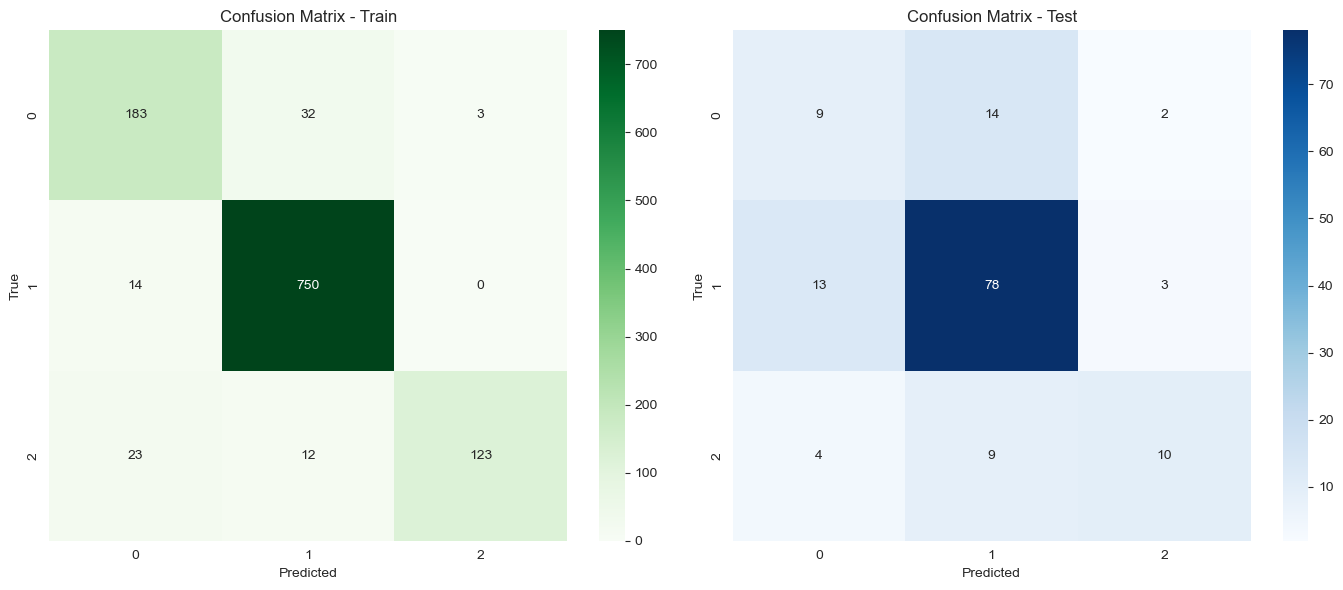


نمونه‌های تصادفی آموزش و پیش‌بینی مدل:
نمونه 1 - ایندکس 788 - لیبل واقعی: 1 - پیش‌بینی: 1
نمونه 2 - ایندکس 904 - لیبل واقعی: 1 - پیش‌بینی: 1
نمونه 3 - ایندکس 289 - لیبل واقعی: 0 - پیش‌بینی: 0
نمونه 4 - ایندکس 1040 - لیبل واقعی: 2 - پیش‌بینی: 2
نمونه 5 - ایندکس 332 - لیبل واقعی: 0 - پیش‌بینی: 1

نمونه‌های تصادفی تست و پیش‌بینی مدل:
نمونه 1 - ایندکس 94 - لیبل واقعی: 1 - پیش‌بینی: 1
نمونه 2 - ایندکس 125 - لیبل واقعی: 2 - پیش‌بینی: 2
نمونه 3 - ایندکس 98 - لیبل واقعی: 1 - پیش‌بینی: 1
نمونه 4 - ایندکس 87 - لیبل واقعی: 0 - پیش‌بینی: 1
نمونه 5 - ایندکس 38 - لیبل واقعی: 1 - پیش‌بینی: 1


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np

# تنظیمات اولیه
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 8
learning_rate = 0.0008
epochs = 40

# تنظیم seed برای reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# فرض می‌کنیم متغیرهای X_train, X_test, y_train, y_test از قبل ساخته شده باشند (از کد استخراج فیچر)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_enc, dtype=torch.long).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# تعریف شبکه MLP
class SimpleNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
num_classes = len(le.classes_)
model = SimpleNN(input_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# توابع آموزش و ارزیابی
def train(model, loader):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    return running_loss / len(loader.dataset)

def evaluate_with_loss(model, loader, criterion):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    return np.array(all_labels), np.array(all_preds), avg_loss

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    sens = recall_score(y_true, y_pred, average='macro')

    cm = confusion_matrix(y_true, y_pred)
    tn = []
    fp = []
    for i in range(len(cm)):
        true_neg = np.delete(np.delete(cm, i, axis=0), i, axis=1).sum()
        false_pos = np.delete(cm[:, i], i).sum()
        tn.append(true_neg)
        fp.append(false_pos)
    spec_per_class = [tn[i] / (tn[i] + fp[i]) if (tn[i] + fp[i]) > 0 else 0 for i in range(len(cm))]
    spec = np.mean(spec_per_class)
    return acc, balanced_acc, spec, sens, f1

best_acc = 0
train_losses = []
test_losses = []

# حلقه آموزش
for epoch in range(epochs):
    train_loss = train(model, train_loader)
    y_true_train, y_pred_train, train_loss_eval = evaluate_with_loss(model, train_loader, criterion)
    y_true_test, y_pred_test, test_loss = evaluate_with_loss(model, test_loader, criterion)

    train_losses.append(train_loss_eval)
    test_losses.append(test_loss)

    train_acc = (y_true_train == y_pred_train).mean()
    test_acc = (y_true_test == y_pred_test).mean()

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss_eval:.4f} - Test Loss: {test_loss:.4f} - Train Acc: {train_acc:.4f} - Test Acc: {test_acc:.4f}")

# بارگذاری بهترین مدل
model.load_state_dict(torch.load("best_model.pth"))

train_acc, train_bal_acc, train_spec, train_sens, train_f1 = compute_metrics(y_true_train, y_pred_train)
test_acc, test_bal_acc, test_spec, test_sens, test_f1 = compute_metrics(y_true_test, y_pred_test)

print("\n✨ دقت‌ها روی داده‌های آموزش:")
print(f"Accuracy: {train_acc:.4f}")
print(f"Balanced Accuracy: {train_bal_acc:.4f}")
print(f"Specificity: {train_spec:.4f}")
print(f"Sensitivity (Recall): {train_sens:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n✨ دقت‌ها روی داده‌های تست:")
print(f"Accuracy: {test_acc:.4f}")
print(f"Balanced Accuracy: {test_bal_acc:.4f}")
print(f"Specificity: {test_spec:.4f}")
print(f"Sensitivity (Recall): {test_sens:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# ماتریس درهم‌ریختگی
labels = le.classes_

cm_train = confusion_matrix(y_true_train, y_pred_train, labels=np.arange(len(labels)))
cm_test = confusion_matrix(y_true_test, y_pred_test, labels=np.arange(len(labels)))

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title('Confusion Matrix - Train')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title('Confusion Matrix - Test')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# نمونه‌های تصادفی پیش‌بینی شده
train_samples_idx = np.random.choice(len(X_train), size=5, replace=False)
test_samples_idx = np.random.choice(len(X_test), size=5, replace=False)

model.eval()
with torch.no_grad():
    X_train_sample = torch.tensor(X_train[train_samples_idx], dtype=torch.float32).to(device)
    pred_train_sample = model(X_train_sample)
    pred_train_labels = le.inverse_transform(pred_train_sample.argmax(dim=1).cpu().numpy())

    X_test_sample = torch.tensor(X_test[test_samples_idx], dtype=torch.float32).to(device)
    pred_test_sample = model(X_test_sample)
    pred_test_labels = le.inverse_transform(pred_test_sample.argmax(dim=1).cpu().numpy())

print("\nنمونه‌های تصادفی آموزش و پیش‌بینی مدل:")
for i, idx in enumerate(train_samples_idx):
    print(f"نمونه {i+1} - ایندکس {idx} - لیبل واقعی: {le.inverse_transform([y_train_enc[idx]])[0]} - پیش‌بینی: {pred_train_labels[i]}")

print("\nنمونه‌های تصادفی تست و پیش‌بینی مدل:")
for i, idx in enumerate(test_samples_idx):
    print(f"نمونه {i+1} - ایندکس {idx} - لیبل واقعی: {le.inverse_transform([y_test_enc[idx]])[0]} - پیش‌بینی: {pred_test_labels[i]}")
